# Домашняя работа №1

Боса Сандра (ИСУ: 408315)

## **1. Постановка задачи**

### **Бизнес-постановка**
Банк хочет автоматически оценивать кредитоспособность заявителя на этапе
подачи заявки, чтобы минимизировать финансовые потери от невозврата кредитов.
Система должна предсказывать, допустит ли клиент дефолт, и помогать
кредитным менеджерам принимать более взвешенные решения.

### **ML-задача**
Бинарная классификация: по характеристикам заявителя предсказать,
допустит ли он дефолт по кредиту

(1 - дефолт, 0 - кредит выплачен).

### **Датасет**

Для решения задачи используется датасет **Credit Risk Dataset** - [ссылка на Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset), содержащий информацию о заемщиках.

В датасете представлены следующие типы признаков:
- демографические характеристики (возраст, доход)
- информация о кредите (сумма кредита, процентная ставка)
- кредитная история (длина кредитной истории, наличие дефолтов)

Целевая переменная:
- loan_status:
  - 0 — кредит выплачен
  - 1 — дефолт



## **2. Выбор метрики для оценки качества модели**

### **Почему не Accuracy?**
В нашей задаче классы несбалансированы: 78% примеров без дефолта, 21% с дефолтом.
Если модель просто предскажет "0" (нет дефолта) для всех примеров, она получит 78% accuracy -
но при этом не поймает ни одного реального дефолта, это неприемлемо для банка.

### **Выбранная метрика: ROC-AUC (Area Under the ROC Curve)**

**Определение**: ROC-AUC измеряет способность модели различать два класса при различных порогах классификации.
Значение от 0 до 1: 0.5 = случайное угадывание, 1.0 = идеальная модель.

**Почему ROC-AUC подходит для нашей задачи**:
1. **Не зависит от дисбаланса классов** - корректно оценивает модель даже при 78/21 разделении
2. **Учитывает оба типа ошибок**:
   - True Positive Rate (TPR) = Recall = доля найденных дефолтов
   - False Positive Rate (FPR) = доля ложных тревог (неправильно предсказал дефолт)
3. **Бизнес-смысл**: банк хочет максимизировать поимку рискованных клиентов, минимизируя ложные тревоги

**Альтернатива**: Recall (полнота) - доля реально найденных дефолтов.
Но ROC-AUC более универсальна, так как одновременно учитывает обе ошибки.

### **Как мы будем использовать метрику:**
На этапе обучения модели будем оптимизировать ROC-AUC и отслеживать её на валидационном наборе.

## **3. EDA (Exploratory Data Analysis)**
## Загрузка данных

Загружаем датасет из CSV файла и смотрим на первые строки,
чтобы убедиться что данные загрузились корректно.

In [ ]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Базовые характеристики датасета

Смотрим на размер датасета, типы колонок, количество пропусков
и базовую статистику по числовым признакам.

In [ ]:
# Размер датасета
print("Размер датасета:", df.shape)
print()

# Типы колонок и пропуски
print("Информация о колонках:")
df.info()
print()

# Базовая статистика по числовым признакам
print("Статистика:")
df.describe()

Размер датасета: (32581, 12)

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Анализ целевой переменной и пропусков

Смотрим насколько сбалансированы классы (дефолт/без дефолта)
и где находятся пропуски в данных.

In [ ]:
# Распределение целевой переменной
print("Распределение целевой переменной (loan_status):")
print(df['loan_status'].value_counts())
print()
print("Процентное соотношение:")
print(df['loan_status'].value_counts(normalize=True) * 100)
print()

# Пропуски
print("Количество пропусков по каждой колонке:")
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print("Процент пропусков:")
print((missing / len(df) * 100)[missing > 0])

Распределение целевой переменной (loan_status):
loan_status
0    25473
1     7108
Name: count, dtype: int64

Процентное соотношение:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Количество пропусков по каждой колонке:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Процент пропусков:
person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64


Видим, что в целевой переменной есть дисбаланс: 78% примеров без дефолта, 21% с дефолтом. Это значит, что точность (accuracy) не будет хорошей метрикой - модель может просто предсказывать "0" для всех и получить 78% точность. Нужно использовать ROC-AUC или Recall, чтобы поймать те редкие дефолты.

## Распределения числовых признаков

Смотрим гистограммы возраста, дохода, суммы кредита и процентной ставки.
Помогает понять, какие значения типичны, есть ли выбросы.

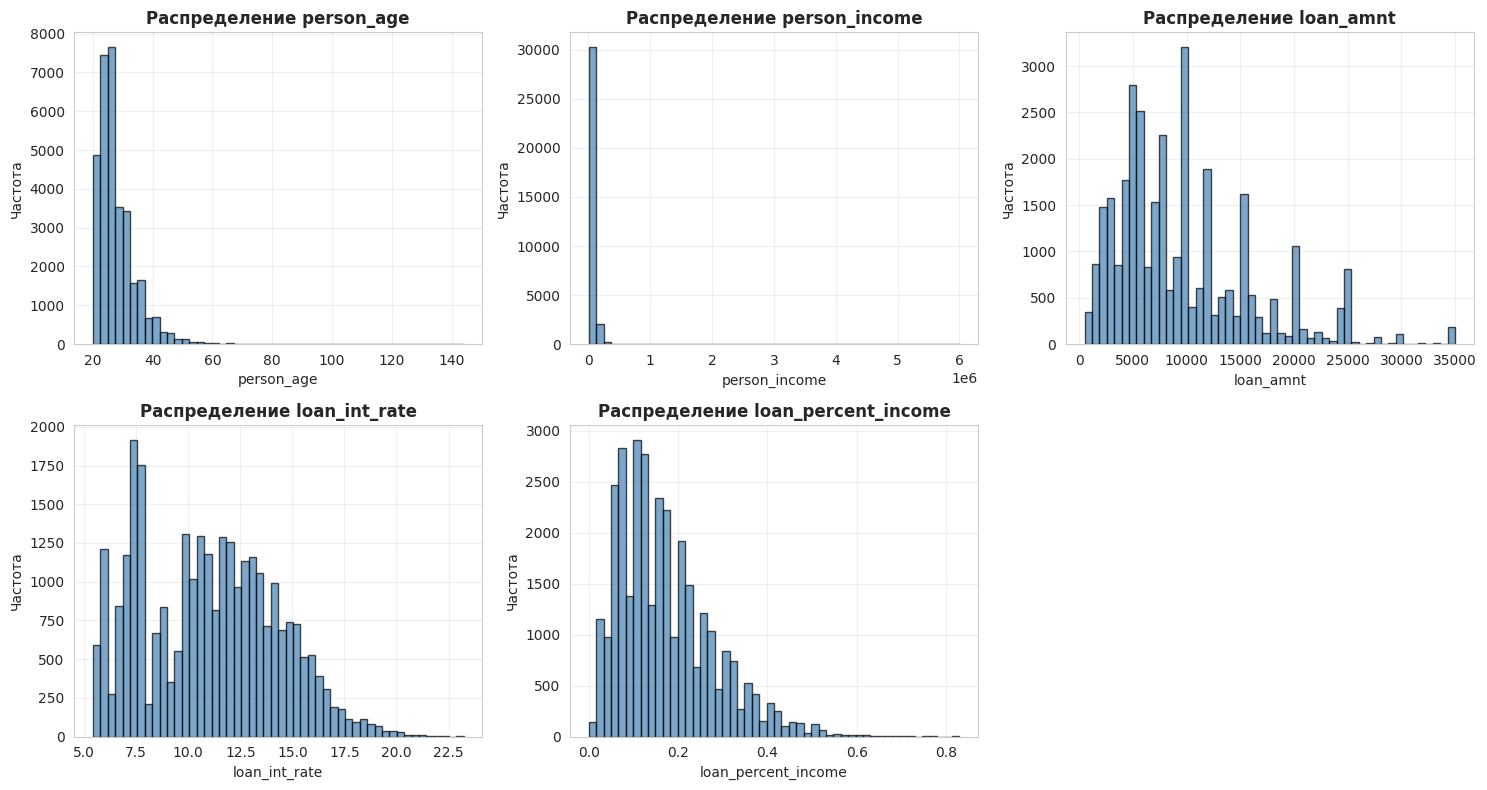

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Числовые колонки (кроме целевой переменной)
numeric_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(True, alpha=0.3)

# Скрыть пустую ячейку
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Связь признаков с дефолтом

Анализируем, как средние значения признаков отличаются
между кредитами с дефолтом и без дефолта.

Средние значения признаков по классам:
             person_age  person_income     loan_amnt  loan_int_rate  \
loan_status                                                           
0             27.807129   70804.361559   9237.464178      10.435999   
1             27.474676   49125.652223  10850.502954      13.060207   

             loan_percent_income  
loan_status                       
0                       0.148805  
1                       0.246889  



/tmp/ipykernel_579/3802707264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y=col, ax=axes[idx], palette='Set2')
/tmp/ipykernel_579/3802707264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y=col, ax=axes[idx], palette='Set2')
/tmp/ipykernel_579/3802707264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y=col, ax=axes[idx], palette='Set2')
/tmp/ipykernel_579/3802707264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

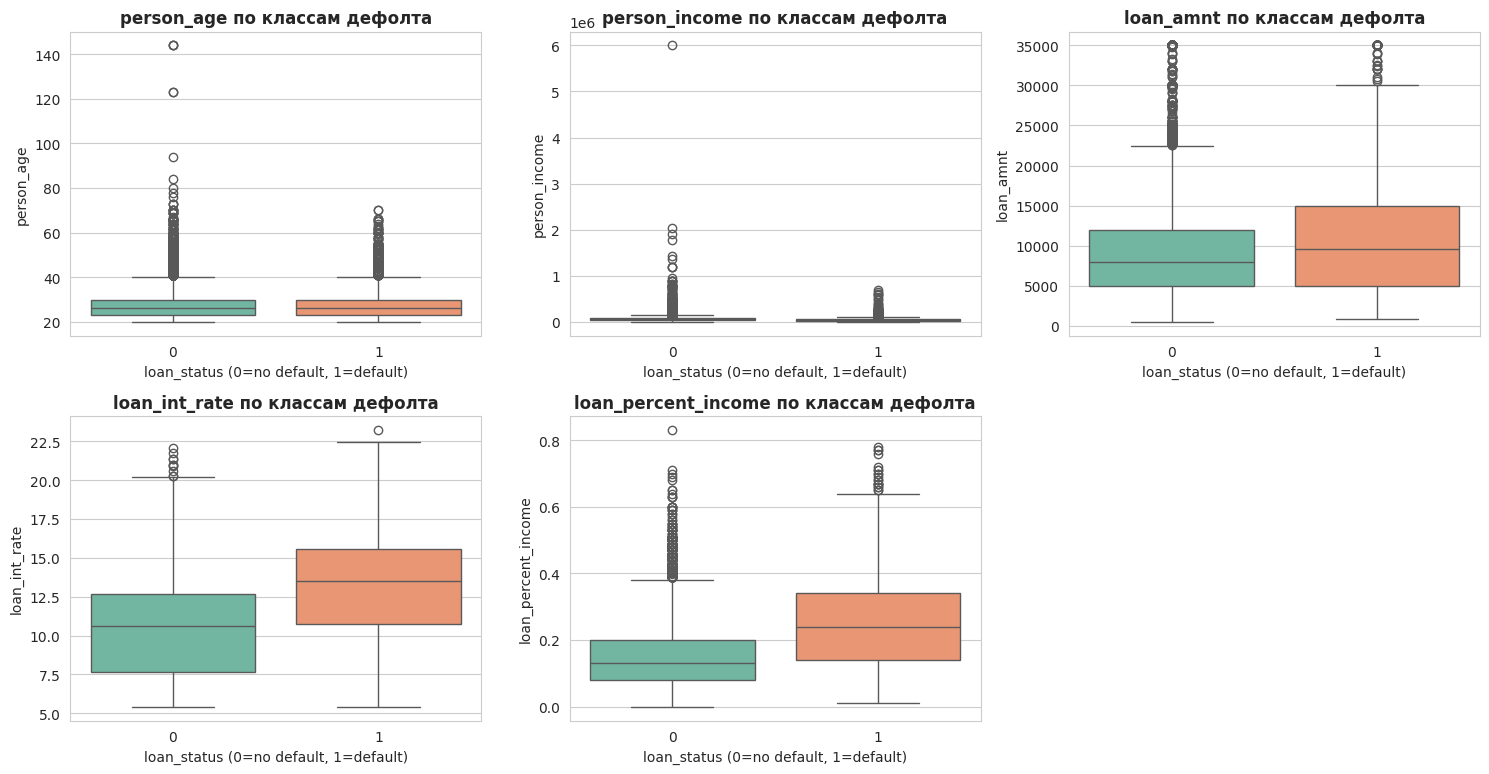

In [ ]:
# Средние значения для каждого класса
print("Средние значения признаков по классам:")
print(df.groupby('loan_status')[numeric_cols].mean())
print()

# Визуализация: boxplot для числовых признаков по классам дефолта
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='loan_status', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} по классам дефолта', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('loan_status (0=no default, 1=default)')

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


Самые важные признаки для предсказания дефолта - это процентная ставка и отношение кредита к доходу. Это имеет бизнес-смысл: банк выдаёт под высокий% рискованным клиентам.

## Анализ категориальных признаков

Смотрим, какие категории есть в данных и как они влияют на дефолт.

Категориальные признаки: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


person_home_ownership:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


loan_intent:
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


loan_grade:
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


cb_person_default_on_file:
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64



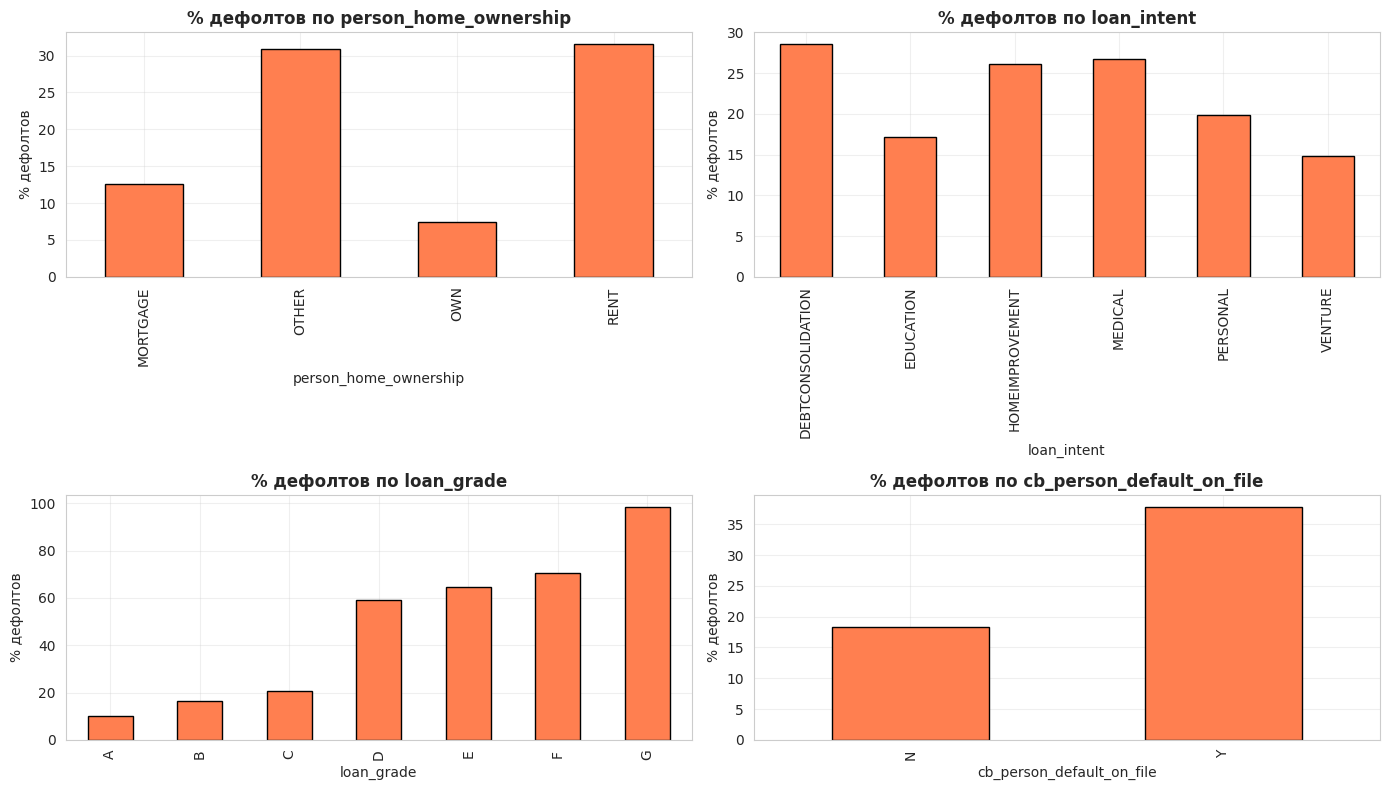

In [ ]:
# Категориальные колонки
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Категориальные признаки:", categorical_cols)
print()

# Распределение по категориям
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print()

# Влияние категорий на дефолт
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < 4:
        # Считаем % дефолтов по каждой категории
        default_by_cat = df.groupby(col)['loan_status'].agg(['sum', 'count'])
        default_by_cat['default_rate'] = (default_by_cat['sum'] / default_by_cat['count'] * 100).round(2)

        default_by_cat['default_rate'].plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
        axes[idx].set_title(f'% дефолтов по {col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('% дефолтов')
        axes[idx].set_xlabel(col)
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Категориальные признаки loan_grade и cb_person_default_on_file имеют огромное влияние на дефолт. Это логично: банк выставляет низкие grade'ы рискованным клиентам, и люди с историей дефолтов более склонны к новому дефолту.

## Корреляция признаков

Смотрим какие числовые признаки сильнее всего коррелируют с дефолтом.



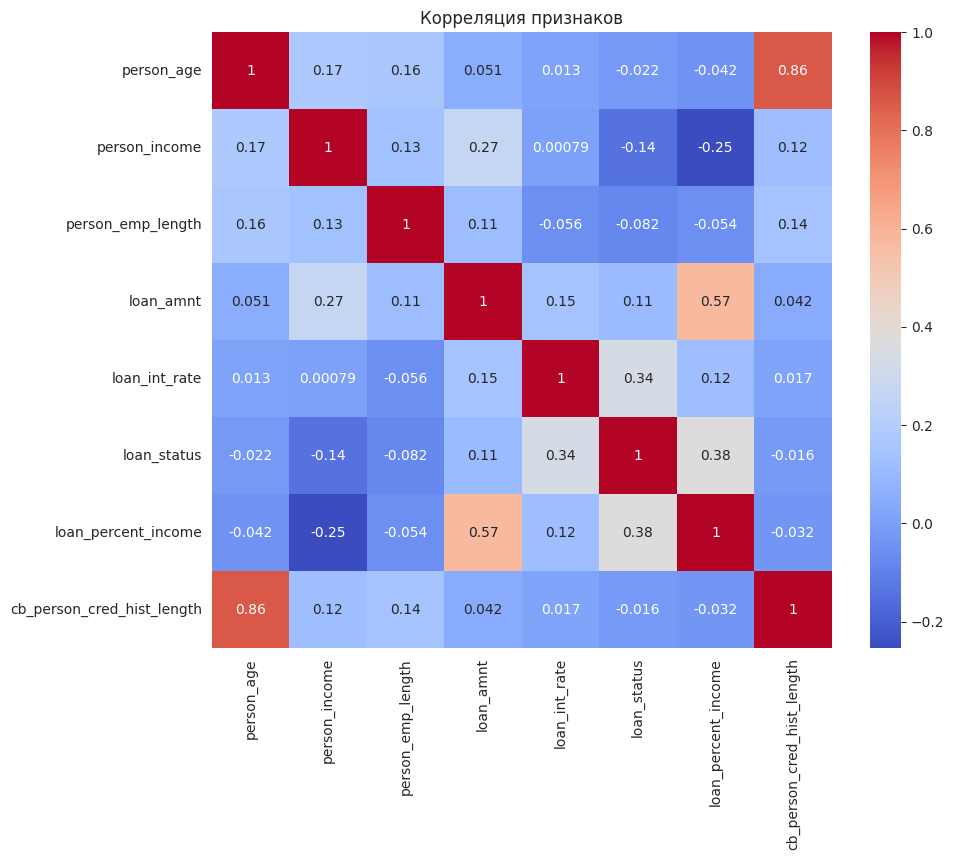

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

## Анализ признаков относительно target

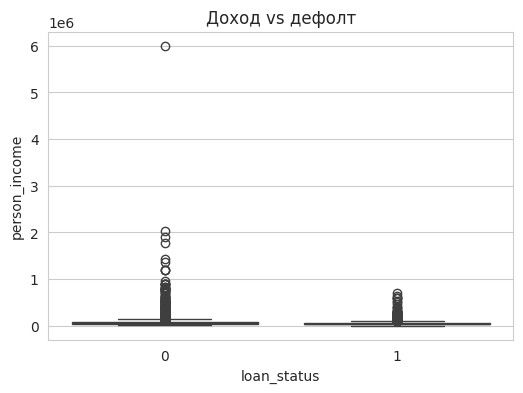

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Доход vs дефолт')
plt.show()

Видно, что распределение дохода различается между группами.

Клиенты с более низким доходом чаще допускают дефолт, что логично с точки зрения бизнеса. Этот признак является важным для модели.

## Проверим выбросы



In [ ]:
# Проверка выбросов
print("Экстремальные значения:")
print(f"person_age max: {df['person_age'].max()}")
print(f"person_income max: {df['person_income'].max()}")
print()

# Строки с возрастом > 100 лет
print("Люди старше 100 лет:")
print(df[df['person_age'] > 100][['person_age', 'loan_status']])

Экстремальные значения:
person_age max: 144
person_income max: 6000000

Люди старше 100 лет:
       person_age  loan_status
81            144            0
183           144            0
575           123            0
747           123            0
32297         144            0


## Выводы по EDA

В ходе разведочного анализа данных были выявлены следующие ключевые особенности:

- Наблюдается дисбаланс классов: доля клиентов с дефолтом значительно ниже, чем доля надежных заемщиков. Это может привести к смещению модели в сторону предсказания класса "без дефолта", поэтому в дальнейшем необходимо учитывать балансировку классов (например, с помощью class weights или oversampling).

- В числовых признаках, таких как доход заемщика (person_income) и сумма кредита, присутствуют выбросы. Это может негативно повлиять на обучение моделей, чувствительных к масштабу данных, поэтому целесообразно рассмотреть методы обработки выбросов или масштабирования признаков.

- Анализ распределения признаков показал, что данные могут быть скошены (не нормальны), что также требует применения методов нормализации или логарифмирования.

- Корреляционный анализ показал наличие умеренных зависимостей между признаками и целевой переменной, что говорит о потенциальной информативности признаков. При этом сильной мультиколлинеарности не наблюдается, что является положительным фактором для обучения моделей.

- Анализ зависимости дохода от целевой переменной показал, что клиенты с более низким доходом чаще допускают дефолт. Это соответствует бизнес-логике и подтверждает значимость данного признака для задачи кредитного скоринга.

- В данных присутствуют пропущенные значения, которые необходимо обработать перед обучением моделей (например, с помощью заполнения медианой или удаления).

## Рекомендации для дальнейшей работы

На основе проведенного анализа можно сделать следующие выводы для последующего моделирования:

- учесть дисбаланс классов при обучении моделей  
- выполнить обработку пропущенных значений  
- применить масштабирование числовых признаков  
- при необходимости обработать выбросы  
- рассмотреть генерацию дополнительных признаков  

Проведенный EDA позволяет лучше понять структуру данных и подготовить их для построения более качественной модели.